# IMPORT LIBRARIES


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, r2_score, silhouette_score,ConfusionMatrixDisplay
)

from mpl_toolkits.mplot3d import Axes3D

 LOAD DATA


In [83]:
df = pd.read_csv("/content/weatherAUS.csv")

print(df.head())
print(df.shape)
print(df.info())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

TARGET ANALYSIS





RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


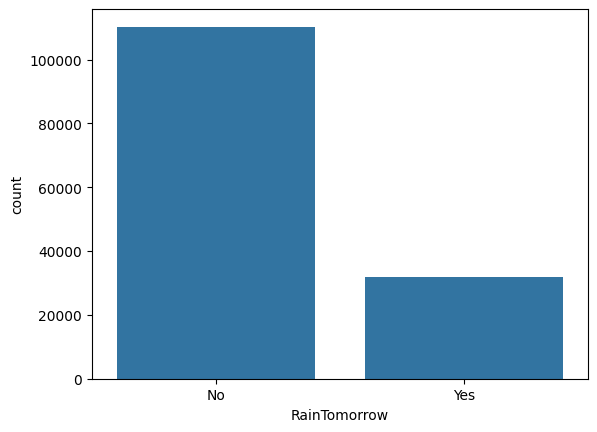

In [84]:
print(df['RainTomorrow'].value_counts())
sns.countplot(x='RainTomorrow', data=df)
plt.show()

MISSING VALUES


In [85]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
print(pd.concat([missing, missing_percent], axis=1, keys=['Missing', 'Percent']))


               Missing    Percent
Sunshine         69835  48.009762
Evaporation      62790  43.166506
Cloud3pm         59358  40.807095
Cloud9am         55888  38.421559
Pressure9am      15065  10.356799
Pressure3pm      15028  10.331363
WindDir9am       10566   7.263853
WindGustDir      10326   7.098859
WindGustSpeed    10263   7.055548
Humidity3pm       4507   3.098446
WindDir3pm        4228   2.906641
Temp3pm           3609   2.481094
RainTomorrow      3267   2.245978
Rainfall          3261   2.241853
RainToday         3261   2.241853
WindSpeed3pm      3062   2.105046
Humidity9am       2654   1.824557
WindSpeed9am      1767   1.214767
Temp9am           1767   1.214767
MinTemp           1485   1.020899
MaxTemp           1261   0.866905
Date                 0   0.000000
Location             0   0.000000


DROP HIGH MISSING COLUMNS

In [86]:
df.drop(columns=[
    'Sunshine',
    'Evaporation',
    'Cloud9am',
    'Cloud3pm'
], inplace=True)

DROP NULL TARGET ROWS

In [87]:
df = df.dropna(subset=['RainTomorrow'])

DATE FEATURE ENGINEERING

In [88]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.drop('Date', axis=1, inplace=True)

ENCODE TARGET

In [89]:
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})

FILL MISSING VALUES

In [90]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

ONE HOT ENCODING

In [91]:
df = pd.get_dummies(df, drop_first=True)

# ======CLASSIFICATION TASK=======


SPLIT DATA

In [92]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

SCALING (LOGISTIC)

In [93]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION


LOGISTIC REGRESSION
Accuracy: 0.8455641900207461
              precision    recall  f1-score   support

           0       0.87      0.95      0.90     22064
           1       0.73      0.49      0.59      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.72      0.75     28439
weighted avg       0.84      0.85      0.83     28439


Confusion Matrix (Logistic Regression):


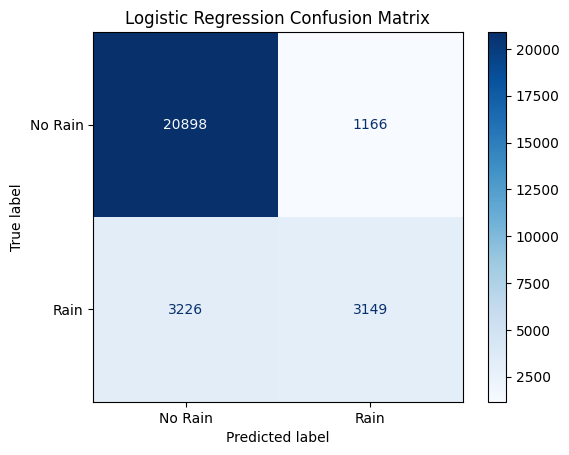

In [94]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("\nLOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print('\nConfusion Matrix (Logistic Regression):')
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No Rain', 'Rain'])
disp_log.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

DECISION TREE



DECISION TREE
Accuracy: 0.8397974612328141

Confusion Matrix (Decision Tree):


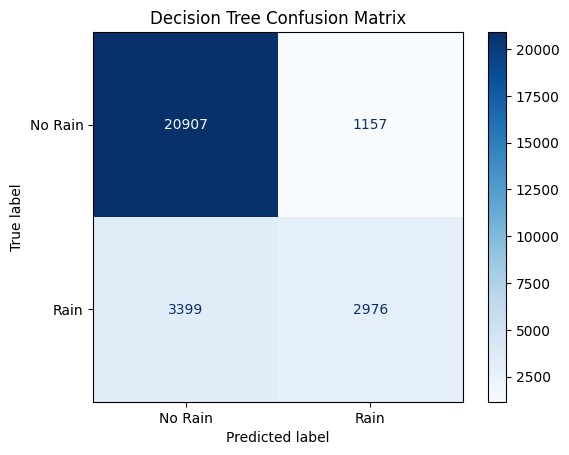

In [95]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\nDECISION TREE")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print('\nConfusion Matrix (Decision Tree):')
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No Rain', 'Rain'])
disp_dt.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.show()

RANDOM FOREST


RANDOM FOREST
Accuracy: 0.854812053869686

Confusion Matrix (Random Forest):


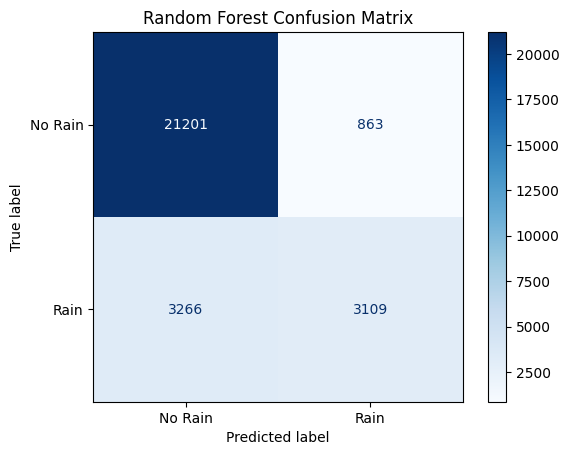

In [96]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nRANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print('\nConfusion Matrix (Random Forest):')
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Rain', 'Rain'])
disp_rf.plot(cmap=plt.cm.Blues)
plt.title('Random Forest Confusion Matrix')
plt.show()

FEATURE IMPORTANCE

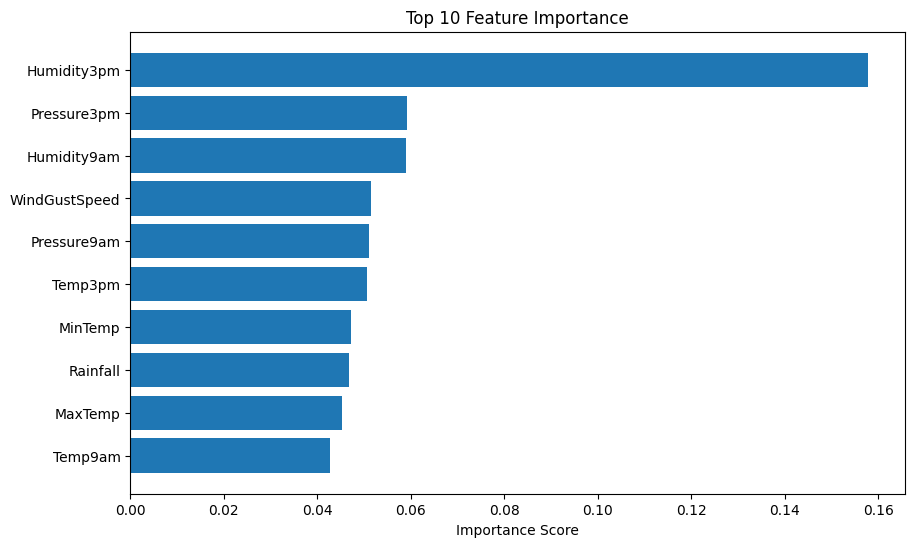

In [97]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.title("Top 10 Feature Importance")

plt.barh(range(len(indices)), importances[indices])

plt.yticks(
    range(len(indices)),
    [X.columns[i] for i in indices]
)

plt.xlabel("Importance Score")
plt.show()

# ========= REGRESSION TASK ===============


LINEAR REGRESSION

In [98]:
X_reg = df.drop(['MaxTemp', 'RainTomorrow'], axis=1, errors='ignore')
y_reg = df['MaxTemp']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

y_pred_r = lr_model.predict(X_test_r)

mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print("\nLINEAR REGRESSION")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


LINEAR REGRESSION
MSE: 1.9758227038035698
RMSE: 1.4056396066572576
R2 Score: 0.9609000157734913


# ================= CLUSTERING TASK =======================


PREPARE DATA

In [99]:
df_cluster = df.drop('RainTomorrow', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

ELBOW METHOD

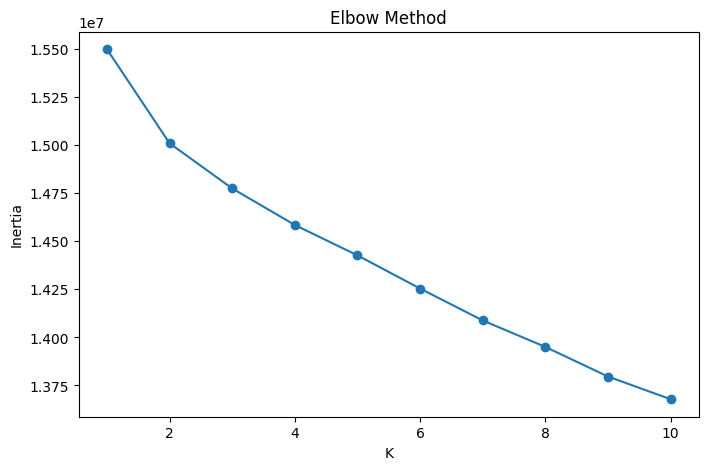

In [100]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

K-MEANS MODEL

In [101]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cluster_result = df.copy()
df_cluster_result['Cluster'] = clusters

SILHOUETTE SCORE

In [102]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.02636226184280926


CLUSTER VISUAL (2D)


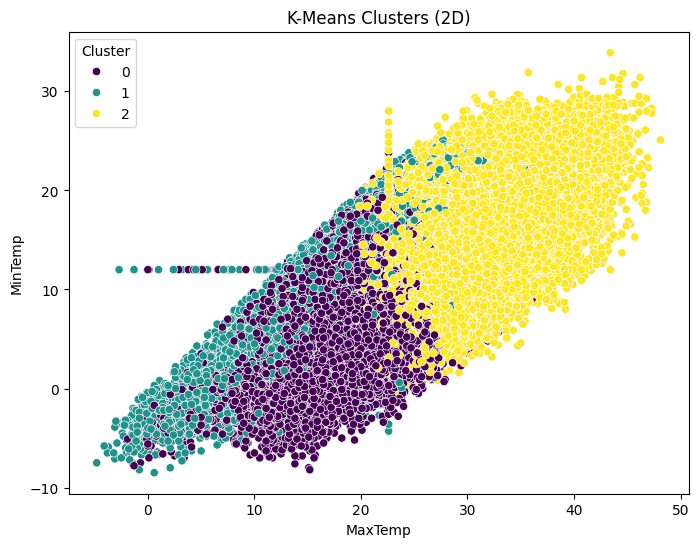

In [103]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_cluster_result['MaxTemp'],
    y=df_cluster_result['MinTemp'],
    hue=df_cluster_result['Cluster'],
    palette='viridis'
)
plt.title("K-Means Clusters (2D)")
plt.show()


PCA 2D

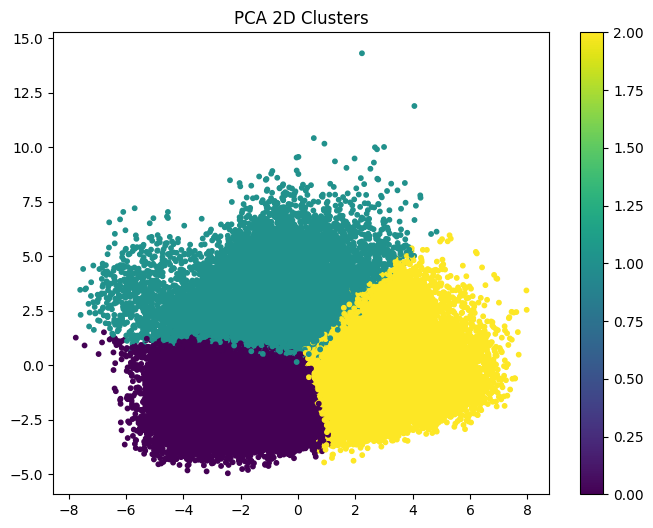

In [104]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=clusters, cmap='viridis', s=10)
plt.title("PCA 2D Clusters")
plt.colorbar()
plt.show()

PCA 3D



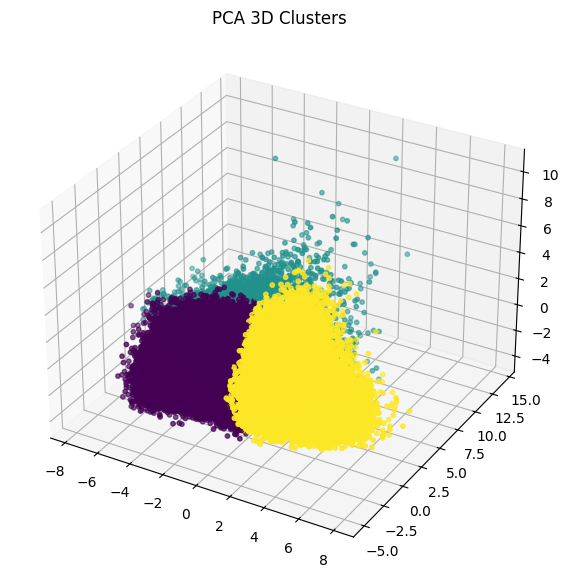

In [105]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=clusters,
    cmap='viridis',
    s=10
)

ax.set_title("PCA 3D Clusters")
plt.show()